# Orange County Analysis

In [1]:
# Import statements
import pandas as pd
import numpy as np

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
# Load in policing data
original_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
from rates_utils import load_census, census_rollup

# Load in census data
census = load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Policing Analysis

Note:
1. In Josh's main analysis, he includes searches that are discretionary only, mixed, and have no basis, only excluding non-discretionary stops, while my analysis is more strict and only includes discretionary stops. In my sensitivty analysis, I check his way, and he checks my way. Should I flip it to match?
2. In Josh's main analysis, he filters to the first person listed per stop in order to conduct stop-level analysis. But is it okay to include all people in each stop? Because what if there's one stop and there's 1 white person and 2 black people and the white person is listed first, and everyone in the car is searched, but only the white person's search is listed. Or vice versa?

In [5]:
from rates_utils import add_standardized_race, policing_rates

# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["action_any_search"] & policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
# Hits only count as hits if they were found in a search, and the search was discretionary
policing["disc_hit"] = (
    policing["disc_search"] & # Has to be from a discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

policing_analysis = policing_rates(policing, census_coarse)
policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Search Rate SE,Hit Rate SE,Population,"Stops per 1,000","Searches per 1,000","Stops per 1,000 SE","Searches per 1,000 SE"
0,2022,Asian,20489,580,188,0.028308,0.324138,0.001159,0.019435,699124,29.306675,0.829610,0.204742,0.034448
1,2022,Black/African American,9361,929,266,0.099242,0.286329,0.003090,0.014831,49304,189.862891,18.842285,1.962361,0.618195
2,2022,Hispanic/Latino,76666,7546,2340,0.098427,0.310098,0.001076,0.005325,1086834,70.540671,6.943103,0.254764,0.079927
3,2022,Other,10946,331,95,0.030239,0.287009,0.001637,0.024864,153072,71.508832,2.162381,0.683490,0.118855
4,2022,White,65084,4259,1627,0.065439,0.382015,0.000969,0.007445,1198655,54.297525,3.553149,0.212835,0.054445
5,2023,Asian,18822,537,164,0.028530,0.305400,0.001213,0.019875,699124,26.922263,0.768104,0.196236,0.033146
6,2023,Black/African American,8400,789,197,0.093929,0.249683,0.003183,0.015409,49304,170.371572,16.002758,1.858906,0.569713
7,2023,Hispanic/Latino,68576,7003,1913,0.102120,0.273169,0.001156,0.005325,1086834,63.097032,6.443486,0.240948,0.076998
8,2023,Other,9753,270,64,0.027684,0.237037,0.001661,0.025881,153072,63.715114,1.763876,0.645169,0.107346
9,2023,White,55658,3470,1312,0.062345,0.378098,0.001025,0.008232,1198655,46.433711,2.894911,0.196820,0.049144


## Publication-Level Tables

In [7]:
from visualization_utils import fmt_est_ci, make_pivot_with_ci

race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

pop = (df[["Perceived Race", "Population"]]
       .drop_duplicates("Perceived Race")
       .set_index("Perceived Race")
       .reindex(race_order))

stops_1k = make_pivot_with_ci(df, "Stops per 1,000", "Stops per 1,000 SE")
searches_1k = make_pivot_with_ci(df, "Searches per 1,000", "Searches per 1,000 SE")

In [8]:
table1 = pd.concat(
    [pop, stops_1k, searches_1k],
    axis=1,
    keys=["Population", "Stops per 1,000", "Searches per 1,000"]
)


table1.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table1.columns],
    names=["", "Year"]
)

table1

Population Stops per 1,000                  \
Year                   Population            2022            2023   
Perceived Race                                                      
Black/African American      49304  189.86 (±3.85)  170.37 (±3.64)   
Hispanic/Latino           1086834   70.54 (±0.50)   63.10 (±0.47)   
White                     1198655   54.30 (±0.42)   46.43 (±0.39)   
Asian                      699124   29.31 (±0.40)   26.92 (±0.38)   
Other                      153072   71.51 (±1.34)   63.72 (±1.26)   

                                       Searches per 1,000                 \
Year                              2024               2022           2023   
Perceived Race                                                             
Black/African American  196.70 (±3.91)      18.84 (±1.21)  16.00 (±1.12)   
Hispanic/Latino          78.28 (±0.53)       6.94 (±0.16)   6.44 (±0.15)   
White                    55.09 (±0.42)       3.55 (±0.11)   2.89 (±0.10)   
Asian                    31.68 (±0.42)       0.83 (±0.07)   0.77 (±0.06)   
Other                    84.39 (±1.46)       2.16 (±0.23)   1.76 (±0.21)   

                                       
Year                             2024  
Perceived Race                         
Black/African American  18.50 (±1.20)  
Hispanic/Latino          8.46 (±0.17)  
White                    3.61 (±0.11)  
Asian                    0.80 (±0.07)  
Other                    2.81 (±0.27)

In [9]:
tab2 = df.copy()

# Convert proportions to percentages
tab2["Search Rate"] *= 100
tab2["Hit Rate"] *= 100
tab2["Search Rate SE"] *= 100
tab2["Hit Rate SE"] *= 100

search_rate = make_pivot_with_ci(tab2, "Search Rate", "Search Rate SE")
hit_rate    = make_pivot_with_ci(tab2, "Hit Rate", "Hit Rate SE")

table2 = pd.concat([search_rate, hit_rate], axis=1, keys=["Search Rate (%)", "Hit Rate (%)"])

table2.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table2.columns],
    names=["", "Year"]
)

table2 = table2.reindex(race_order)
table2

Search Rate (%)                                \
Year                              2022           2023           2024   
Perceived Race                                                         
Black/African American    9.92 (±0.61)   9.39 (±0.62)   9.40 (±0.58)   
Hispanic/Latino           9.84 (±0.21)  10.21 (±0.23)  10.80 (±0.21)   
White                     6.54 (±0.19)   6.23 (±0.20)   6.55 (±0.19)   
Asian                     2.83 (±0.23)   2.85 (±0.24)   2.52 (±0.21)   
Other                     3.02 (±0.32)   2.77 (±0.33)   3.33 (±0.31)   

                         Hit Rate (%)                                
Year                             2022           2023           2024  
Perceived Race                                                       
Black/African American  28.63 (±2.91)  24.97 (±3.02)  24.67 (±2.80)  
Hispanic/Latino         31.01 (±1.04)  27.32 (±1.04)  26.16 (±0.90)  
White                   38.20 (±1.46)  37.81 (±1.61)  34.12 (±1.41)  
Asian                   32.41 (±3.81)  30.54 (±3.90)  30.47 (±3.82)  
Other                   28.70 (±4.87)  23.70 (±5.07)  26.05 (±4.15)

## Publication-Level Figures

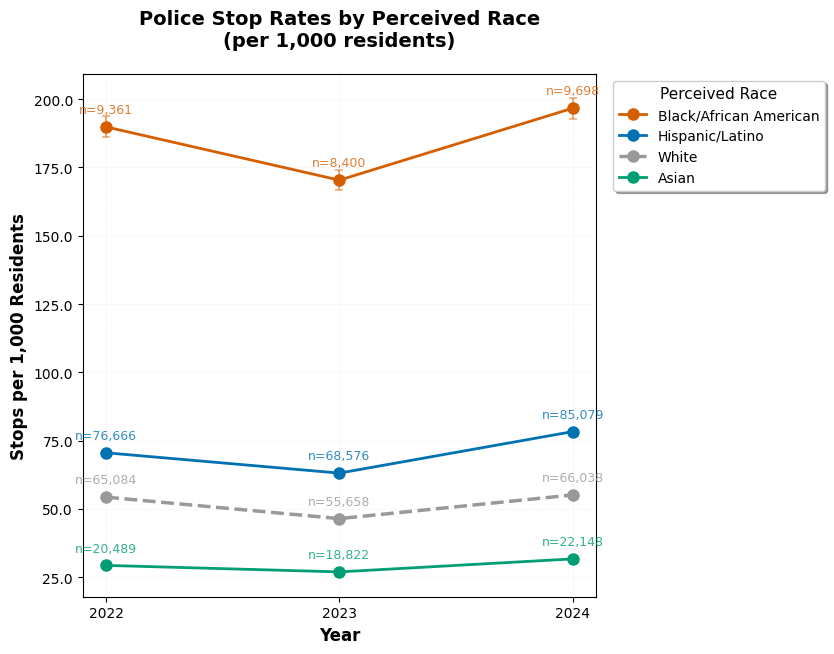

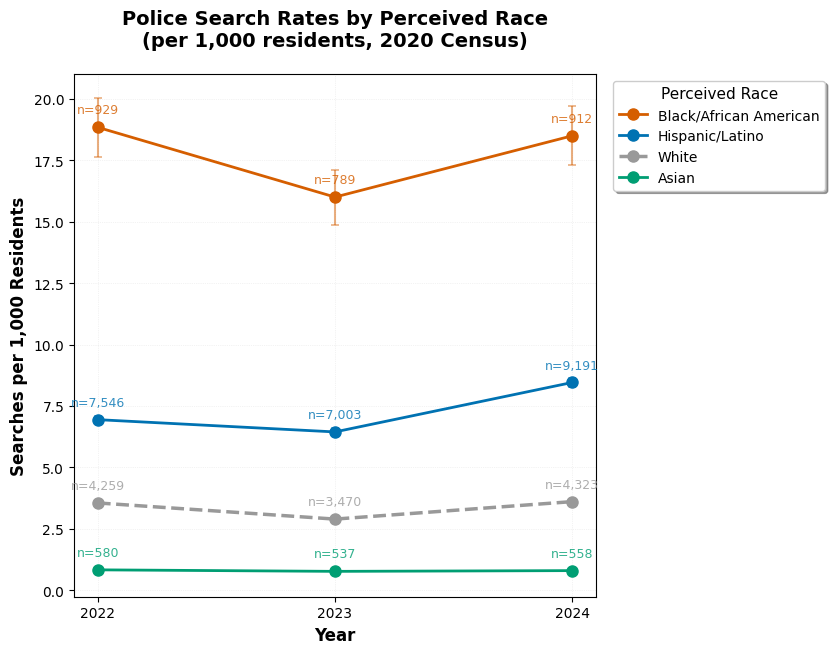

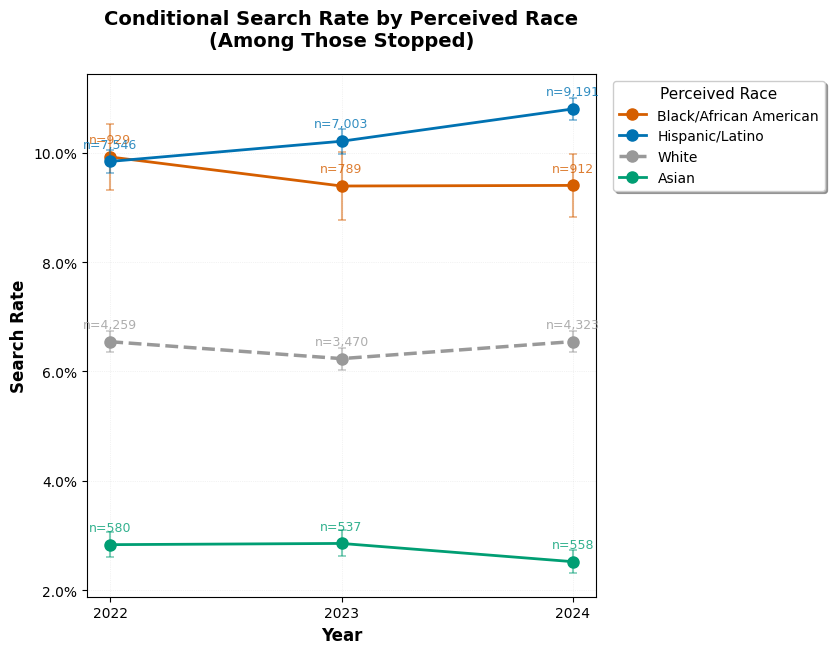

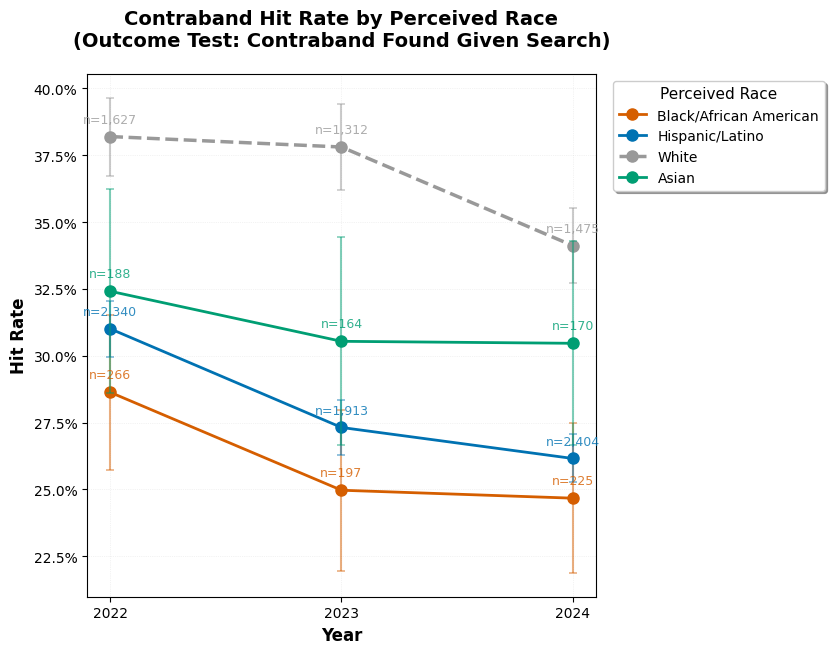

In [10]:
from visualization_utils import(visualize_policing, export_figures_to_pdf)  # noqa: F401

policing_figs = visualize_policing(policing_analysis)
# export_figures_to_pdf(policing_figs, output_dir='../output')

# Policing Sensitivity Analysis: Mixed Search Bases

In [11]:
from rates_utils import policing_rates_mixed

# Create alternative classification: treat mixed searches as discretionary
policing["disc_search_mixed"] = policing["action_any_search"] & policing["search_type"].isin(["Discretionary only", "Mixed", "No search basis"])

# Create discretionary search indicator
policing["disc_hit_mixed"] = (
    policing["disc_search_mixed"] & # Cannot be from a non-discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Compute policing rates using mixed classification
policing_analysis_mixed = policing_rates_mixed(policing, census_coarse)
display(policing_analysis_mixed)

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Search Rate SE,Hit Rate SE,Population,"Stops per 1,000","Searches per 1,000","Stops per 1,000 SE","Searches per 1,000 SE"
0,2022,Asian,20489,801,297,0.039094,0.370787,0.001354,0.017067,699124,29.306675,1.145720,0.204742,0.040482
1,2022,Black/African American,9361,1316,468,0.140583,0.355623,0.003593,0.013196,49304,189.862891,26.691546,1.962361,0.735776
2,2022,Hispanic/Latino,76666,10111,3544,0.131884,0.350509,0.001222,0.004745,1086834,70.540671,9.303169,0.254764,0.092520
3,2022,Other,10946,445,144,0.040654,0.323596,0.001888,0.022178,153072,71.508832,2.907129,0.683490,0.137811
4,2022,White,65084,6030,2598,0.092649,0.430846,0.001137,0.006377,1198655,54.297525,5.030639,0.212835,0.064784
5,2023,Asian,18822,737,256,0.039156,0.347354,0.001414,0.017538,699124,26.922263,1.054176,0.196236,0.038831
6,2023,Black/African American,8400,1179,376,0.140357,0.318914,0.003790,0.013573,49304,170.371572,23.912867,1.858906,0.696426
7,2023,Hispanic/Latino,68576,9788,3261,0.142732,0.333163,0.001336,0.004764,1086834,63.097032,9.005975,0.240948,0.091030
8,2023,Other,9753,403,125,0.041321,0.310174,0.002015,0.023042,153072,63.715114,2.632748,0.645169,0.131147
9,2023,White,55658,5049,2234,0.090715,0.442464,0.001217,0.006990,1198655,46.433711,4.212221,0.196820,0.059280


## Publication-Level Table

In [12]:
def make_2024_block(df, label):
    """Return a 2024 table with formatted Search/Hit rates for one method."""
    d = df[df["Year"] == 2024].copy()

    out = pd.DataFrame(index=d["Perceived Race"])
    out[( "Search Rate (%)", label)] = [fmt_est_ci(e, s, 2) for e, s in zip(d["Search Rate"], d["Search Rate SE"])]
    out[( "Hit Rate (%)",    label)] = [fmt_est_ci(e, s, 2) for e, s in zip(d["Hit Rate"],    d["Hit Rate SE"])]
    return out

# Make safe copies
strict_df = policing_analysis.copy()
mixed_df  = policing_analysis_mixed.copy()

# Convert to percentages ONLY if stored as proportions
for d in (strict_df, mixed_df):
    if d["Search Rate"].max() <= 1:
        d[["Search Rate", "Hit Rate",
           "Search Rate SE", "Hit Rate SE"]] *= 100

strict_2024 = make_2024_block(strict_df, "Strict")
mixed_2024  = make_2024_block(mixed_df, "Mixed")

table3 = strict_2024.join(mixed_2024, how="outer")

# Enforce race order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table3 = table3.reindex(race_order)

table3 = table3[[("Search Rate (%)","Strict"), ("Search Rate (%)","Mixed"),
                 ("Hit Rate (%)","Strict"),    ("Hit Rate (%)","Mixed")]]

table3.columns = pd.MultiIndex.from_tuples(table3.columns, names=["", ""])
table3.index.name = "Perceived Race"

table3

Search Rate (%)                  Hit Rate (%)  \
                                Strict          Mixed         Strict   
Perceived Race                                                         
Black/African American    9.40 (±0.58)  13.37 (±0.68)  24.67 (±2.80)   
Hispanic/Latino          10.80 (±0.21)  14.28 (±0.24)  26.16 (±0.90)   
White                     6.55 (±0.19)   9.00 (±0.22)  34.12 (±1.41)   
Asian                     2.52 (±0.21)   3.33 (±0.24)  30.47 (±3.82)   
Other                     3.33 (±0.31)   4.28 (±0.35)  26.05 (±4.15)   

                                       
                                Mixed  
Perceived Race                         
Black/African American  29.53 (±2.48)  
Hispanic/Latino         31.28 (±0.82)  
White                   39.07 (±1.24)  
Asian                   34.96 (±3.44)  
Other                   28.03 (±3.74)

## Publication-Level Figure

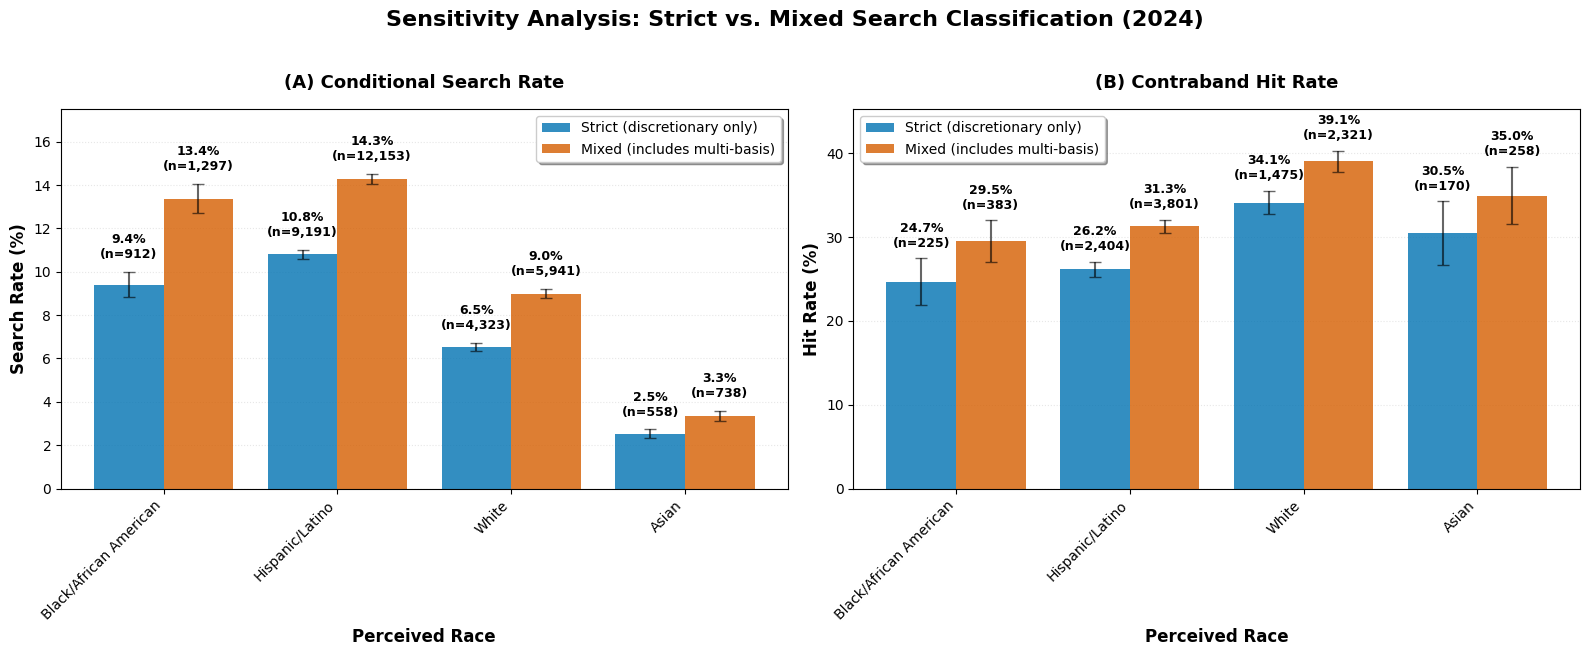

In [13]:
from visualization_utils import create_sensitivity_visualization

# Create the sensitivity analysis figure
sensitivity_fig = create_sensitivity_visualization(
    strict_df=policing_analysis,
    mixed_df=policing_analysis_mixed
)

# export_figures_to_pdf({"sensitivity_analysis": sensitivity_fig}, output_dir='../output')

# Prosecution Analysis: Enhancement Rates by Charge and Statute Level

In [14]:
from rates_utils import categorize_charge, enhancement_rates_by_primary_severity

# Harmonizes race labels
prosecution = add_standardized_race(prosecution, 'canonical_race')

# Identify charges that are enhancements/priors/sentencing considerations rather than actual substantive criminal charges
prosecution['is_non_substantive'] = (
    prosecution['is_enhancement_charge'].astype(bool) |
    prosecution['is_special_circumstance'].astype(bool) |
    prosecution['is_sentencing_charge'].astype(bool)
)

# Apply categorization ONLY to substantive charges
prosecution.loc[~prosecution['is_non_substantive'], 'charge_category'] = \
    prosecution.loc[~prosecution['is_non_substantive'], 'charge_description'].apply(categorize_charge)

# For non-substantive charges, label them explicitly as ehancement/prior/sentencing
prosecution.loc[prosecution['is_non_substantive'], 'charge_category'] = 'Enhancement/Prior/Sentencing'

# Each case is a single defendant, so case-level = defendant-case-level
# For each case, if any charge is an enhancement charge, then the case is flagged as having an enhancement charge
enh_flag = (
    prosecution.groupby('source_case_id')['is_enhancement_charge']
    .max()
    .rename('any_enhancement_in_case')
    .reset_index()
)

# Drop the enhancement rows, keeping only the base charges
substantive = prosecution[~prosecution['is_non_substantive']].copy()

# Add the enhancement flag to the dataframe
substantive = substantive.merge(enh_flag, on='source_case_id', how='left')
substantive['any_enhancement_in_case'] = substantive['any_enhancement_in_case'].fillna(0).astype(int)

# Calculate enhancement rates by charge category
# For each case, a primary charge category and statute level is assigned
# Then computes cases with any enhancement charge over total cases for each charge category
enhancement_by_primary = enhancement_rates_by_primary_severity(substantive)

# Identifies the top 6 charge categories
top6_primary = (
    enhancement_by_primary
        .groupby('primary_charge_category')['N']
        .sum()
        .sort_values(ascending=False)
        .head(6)
        .index
)

# Filters for the top 6 charge categories
enhancement_primary_top6 = enhancement_by_primary[
    enhancement_by_primary['primary_charge_category'].isin(top6_primary)
]

## Publication-Level Tables

In [15]:
from visualization_utils import create_enhancement_summary_table, create_charge_category_table

enhancement_summary_table = create_enhancement_summary_table(enhancement_by_primary)
enhancement_charge_category_table = create_charge_category_table(enhancement_primary_top6)

display(enhancement_summary_table)
display(enhancement_charge_category_table)

,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,Black/African American,Misdemeanor,3119,22.54 (±1.47)
1,,Felony,1173,7.08 (±1.47)
2,Hispanic/Latino,Misdemeanor,31878,25.86 (±0.48)
3,,Felony,7643,7.50 (±0.59)
4,White,Misdemeanor,25136,20.44 (±0.50)
5,,Felony,4767,4.45 (±0.59)
6,Asian,Misdemeanor,3123,29.81 (±1.60)
7,,Felony,686,4.81 (±1.60)
8,Other,Misdemeanor,2710,29.52 (±1.72)
9,,Felony,590,7.29 (±2.10)


,Charge Category,Canonical Race,Number of Cases,Enhancement Rate (%)
0,Drug Possession/Paraphernalia,Black/African American,1181,1.27 (±0.64)
1,,Hispanic/Latino,14255,1.37 (±0.19)
2,,White,12880,0.70 (±0.14)
3,,Asian,1099,1.46 (±0.71)
4,,Other,906,1.99 (±0.91)
5,DUI,Black/African American,719,92.63 (±1.91)
6,,Hispanic/Latino,8474,93.32 (±0.53)
7,,White,5438,90.53 (±0.78)
8,,Asian,962,94.07 (±1.49)
9,,Other,840,91.67 (±1.87)


## Publication-Level Figures

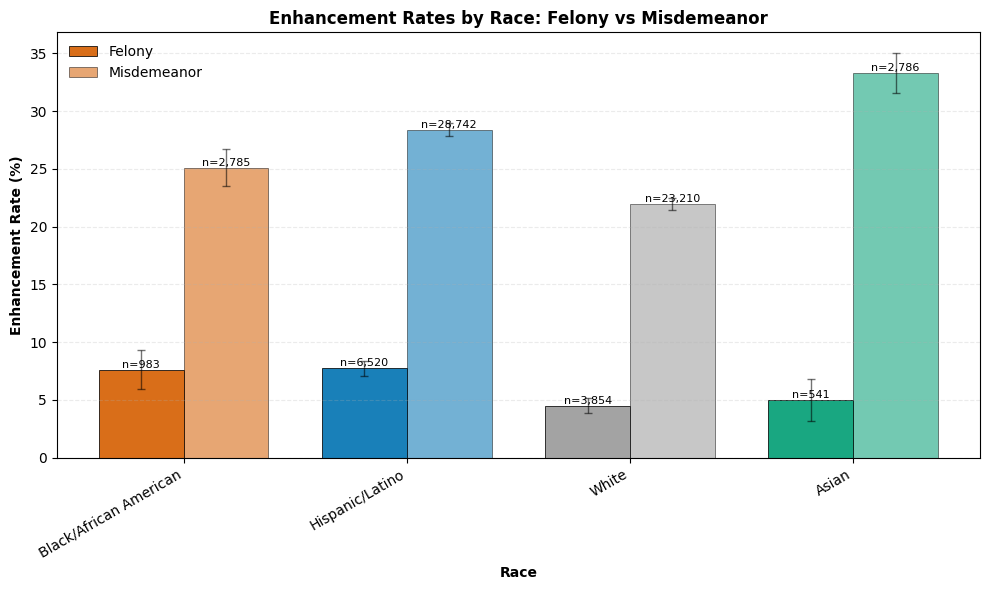

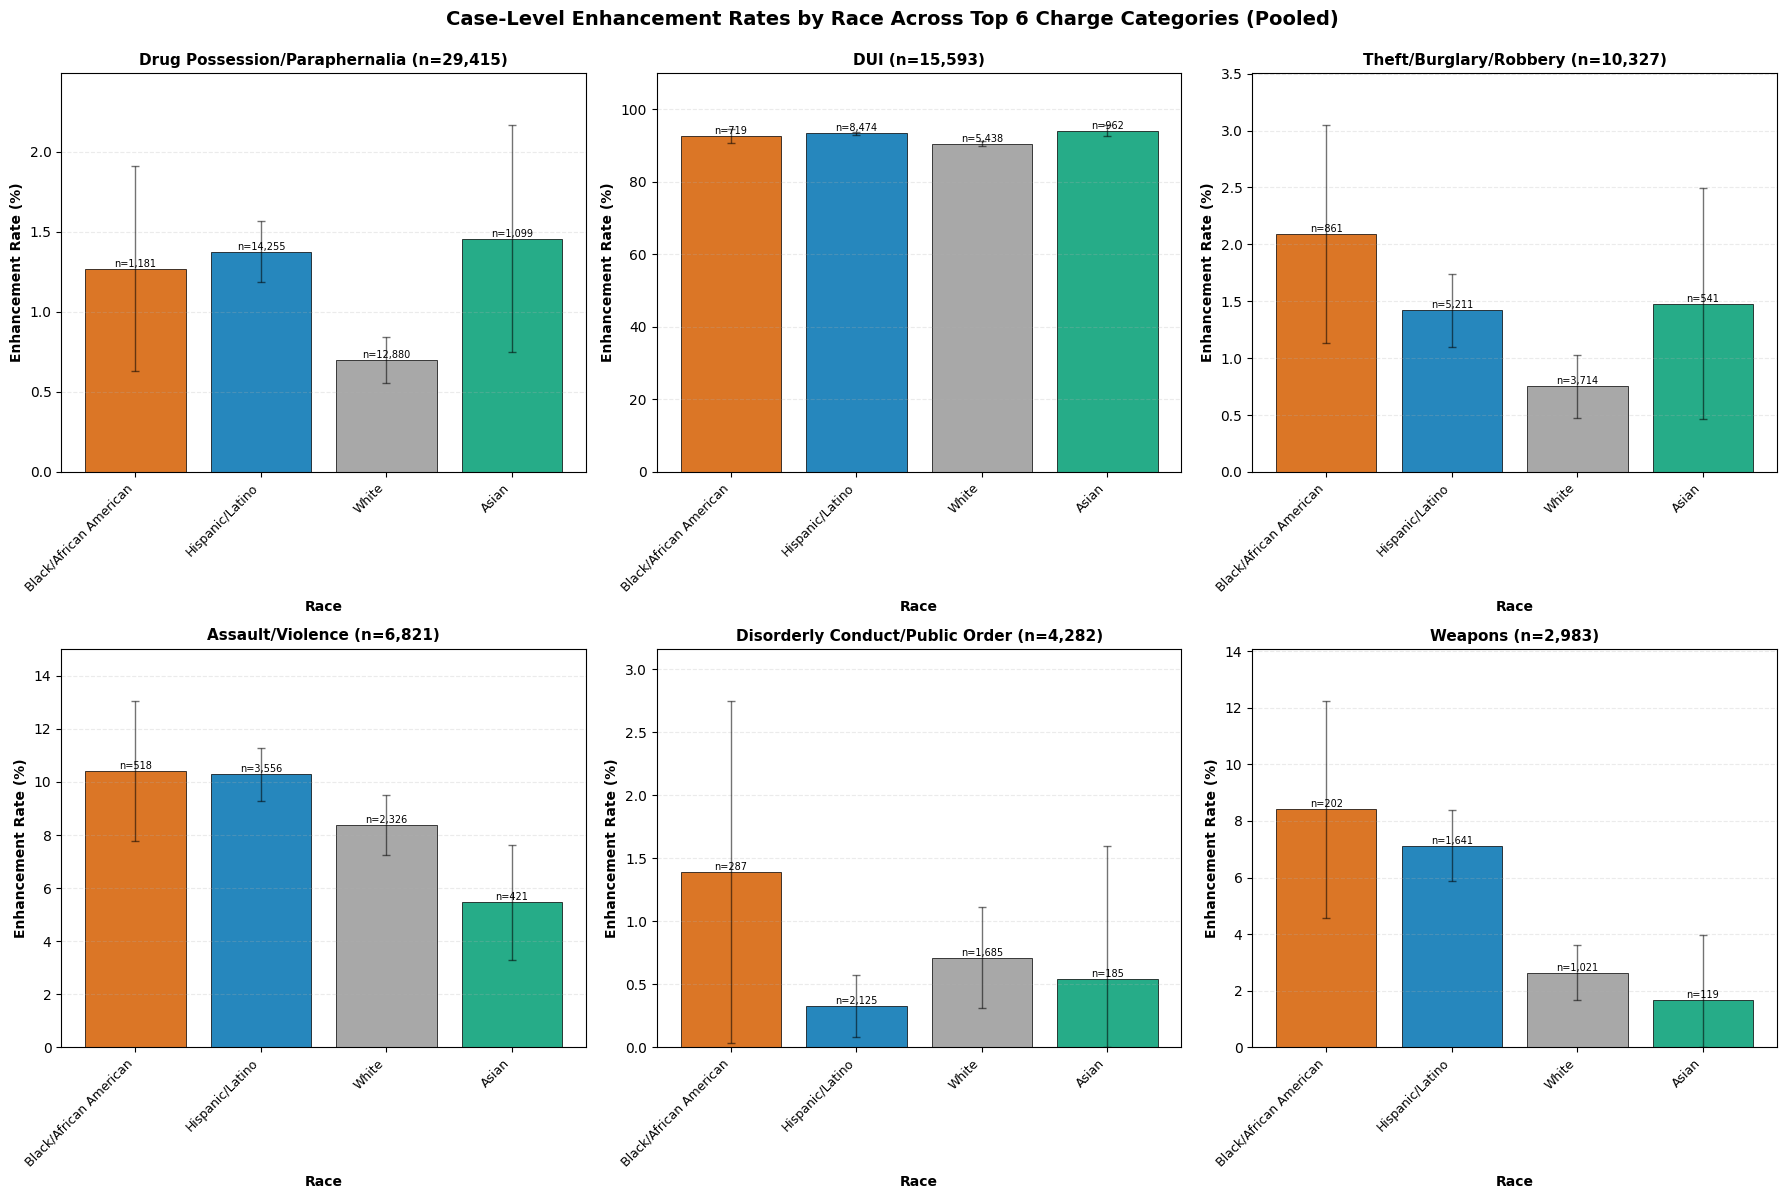

In [16]:
from visualization_utils import plot_felony_vs_misdemeanor_by_race, plot_top6_charge_categories_grid_pooled
from matplotlib import pyplot as plt

fig1 = plot_felony_vs_misdemeanor_by_race(enhancement_primary_top6)
fig2 = plot_top6_charge_categories_grid_pooled(enhancement_primary_top6)

plt.show()

# Prosecution Analysis: Wobblers

In [17]:
# Filter to wobbler charges only
wobblers = substantive[substantive['is_wobbler']].copy()

# Calculate felony rate for wobblers by race
wobbler_summary = (wobblers.groupby(['race_std', 'statute_level']).size().unstack(fill_value=0))


# Calculate felony rate
wobbler_summary['Total'] = wobbler_summary['Felony'] + wobbler_summary['Misdemeanor']
wobbler_summary['Felony Rate'] = wobbler_summary['Felony'] / wobbler_summary['Total']

# Calculate standard error
wobbler_summary['Felony Rate SE'] = np.sqrt(
    wobbler_summary['Felony Rate'] * (1 - wobbler_summary['Felony Rate']) / wobbler_summary['Total']
)

# Sort by felony rate
wobbler_summary = wobbler_summary.sort_values('Felony Rate', ascending=False)
wobbler_summary.index.name = 'Canonical Race'


# Create a formatted table for publication
wobbler_table = wobbler_summary[['Felony', 'Misdemeanor', 'Total', 'Felony Rate', 'Felony Rate SE']].copy()
wobbler_table['Felony Rate (%)'] = wobbler_table.apply(
    lambda row: f"{row['Felony Rate']*100:.1f} (±{row['Felony Rate SE']*100*1.96:.1f})", 
    axis=1
)

# Reorder columns
wobbler_table = wobbler_table[['Total', 'Felony', 'Misdemeanor', 'Felony Rate (%)']]
wobbler_table.columns = ['Total Wobblers', 'Filed as Felony', 'Filed as Misdemeanor', 'Felony Rate (%) [95% CI]']

# Enforce race order
wobbler_table = wobbler_table.reindex(race_order)

display(wobbler_table)

,Total Wobblers,Filed as Felony,Filed as Misdemeanor,Felony Rate (%) [95% CI]
Canonical Race,,,,
Black/African American,5684,2927,2757,51.5 (±1.3)
Hispanic/Latino,49976,21438,28538,42.9 (±0.4)
White,35432,11179,24253,31.6 (±0.5)
Asian,4517,1912,2605,42.3 (±1.4)
Other,4532,2124,2408,46.9 (±1.5)


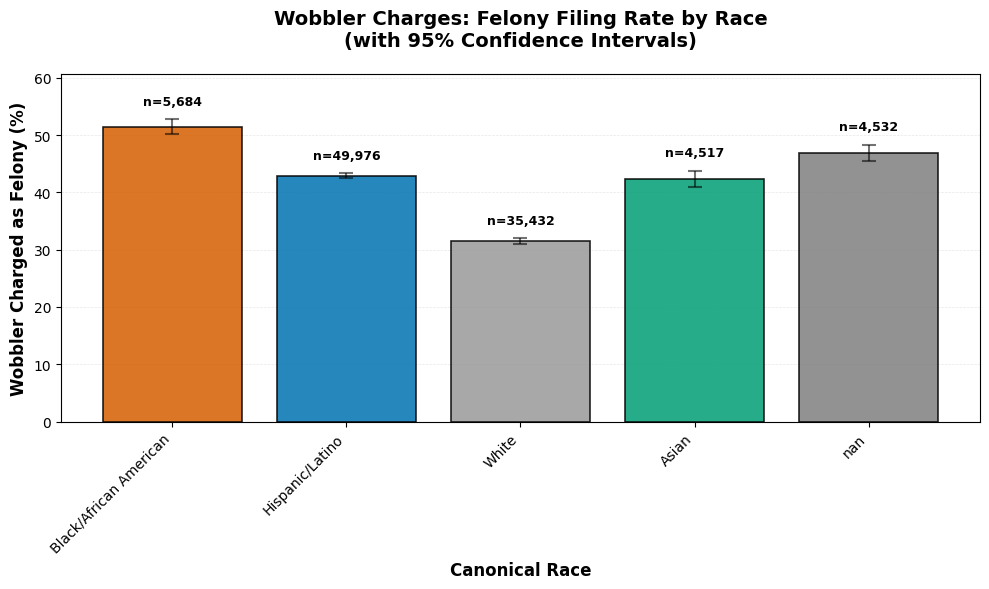

In [18]:
from visualization_utils import plot_wobbler_felony_rates

# Create the wobbler visualization using the harmonized function
wobbler_fig = plot_wobbler_felony_rates(wobbler_summary)
# export_figures_to_pdf({'wobbler_analysis': wobbler_fig}, output_dir='../output')